<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Neural Networks (NN) - MLP Modeling
</p>


## Purpose and evaluation protocol

This notebook implements a time-aware ANN (MLP) pipeline for path loss prediction. The evaluation design follows strict temporal separation to avoid leakage.

Key principles:
- Train/test split is time-ordered (train window precedes test window).
- Model selection is done via time-aware cross-validation on the training window only.
- Feature scaling is fit on the training window and applied to validation/test.
- The held-out test window is used once for final reporting.

Metrics reported: MSE, MAE, RMSE, R2, MAPE, Median AE.


In [1]:
# Imports - core utils, data wrangling, ANN modeling, evaluation, and plotting

# Reproducibility knobs must be set before TensorFlow is imported / runs any op.
import os

GLOBAL_SEED = 50
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
# GPU measured slower than CPU for this notebook's architecture sizes
# (dispatch overhead dominates small dense nets even more than it did for
# the RNN notebook's GRU) -- forced off rather than left to opportunistically
# grab the GPU and silently regress.
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Standard library
import ast
import json
import pickle
import re
import time

# Data handling
import numpy as np
import pandas as pd
from IPython.display import display

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.colors import qualitative
from plotly.subplots import make_subplots

# TensorFlow / Keras
import tensorflow as tf
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import BatchNormalization, Dense, Dropout, Input, ReLU
from keras.models import Sequential
from keras.optimizers import Adam
from keras.regularizers import l2
from tensorflow.keras import backend as K

# ML evaluation and splitting
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
)
from sklearn.preprocessing import StandardScaler
from scipy.stats import linregress

# Reproducibility: seed all RNGs and force deterministic op execution.
# Note: PYTHONHASHSEED only takes effect on a fresh interpreter -- restart
# the kernel once after pulling this change for it to fully apply.
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
tf.config.experimental.enable_op_determinism()

I0000 00:00:1791154960.735319 2733651 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1791154961.651578 2733651 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Data and Preprocessing
</p>


In [2]:
# Paths 
TRAIN_CSV = "Data_Files/train.csv"
TEST_CSV  = "Data_Files/test.csv"
FOLDS_NPY = "Data_Files/train_folds.npy"
CV_SPLITS_NPZ = "Data_Files/train_time_series_cv_splits.npz"

MODELS_DIR     = "Models"
FIGURES_DIR    = "Figures"
CV_RESULTS_DIR = "CV_Results"
RESIDUALS_DIR  = "Residuals"

for directory in [MODELS_DIR, FIGURES_DIR, CV_RESULTS_DIR, RESIDUALS_DIR]:
    os.makedirs(directory, exist_ok=True)

CV_RESULTS_PATH = os.path.join(CV_RESULTS_DIR, "ann_compact_kfold_results_summary.csv")
CV_FOLD_RESULTS_PATH = os.path.join(CV_RESULTS_DIR, "ann_compact_kfold_profile_fold_results.csv")
BEST_PROFILE_PER_ARCH_PATH = os.path.join(CV_RESULTS_DIR, "ann_compact_best_profile_per_architecture.csv")
MODEL_PATH      = os.path.join(MODELS_DIR, "ann_final_model.pkl")

# Load time-aware train/test split and predefined train folds
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)
fold_assignments = np.load(FOLDS_NPY)
fold_assignments = np.asarray(fold_assignments).ravel()
cv_npz = np.load(CV_SPLITS_NPZ)
n_splits = int(cv_npz["n_splits"])
cv_splits = [
    (cv_npz[f"fold_{i}_train_idx"], cv_npz[f"fold_{i}_val_idx"])
    for i in range(n_splits)
]


# Optional datetime parsing for reporting/saving
for df in [df_train, df_test]:
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")

if len(fold_assignments) != len(df_train):
    raise ValueError(
        f"fold_assignments length ({len(fold_assignments)}) does not match "
        f"df_train length ({len(df_train)})"
    )


def validate_cv_splits(cv_splits, fold_assignments, name="cv_splits"):
    fold_ids = sorted(np.unique(fold_assignments[fold_assignments >= 0]).astype(int).tolist())
    if len(cv_splits) != len(fold_ids):
        raise ValueError(f"{name} has {len(cv_splits)} splits but fold metadata has {len(fold_ids)} validation folds.")

    for fold_num, (tr_idx, val_idx) in enumerate(cv_splits):
        tr_idx = np.asarray(tr_idx, dtype=int)
        val_idx = np.asarray(val_idx, dtype=int)
        if tr_idx.size == 0 or val_idx.size == 0:
            raise ValueError(f"{name} fold {fold_num} has an empty train or validation index set.")
        if np.intersect1d(tr_idx, val_idx).size:
            raise ValueError(f"{name} fold {fold_num} has train/validation overlap.")
        if tr_idx.max() >= val_idx.min():
            raise ValueError(f"{name} fold {fold_num} trains on rows at or after its validation window.")

        expected_val_idx = np.flatnonzero(fold_assignments == fold_num)
        if not np.array_equal(val_idx, expected_val_idx):
            raise ValueError(f"{name} fold {fold_num} validation indices do not match train_folds.npy metadata.")


validate_cv_splits(cv_splits, fold_assignments)

feature_columns = [
    "distance", "frequency", "c_walls", "w_walls",
    "co2", "humidity", "pm25", "pressure", "temperature"
]
target_column = "PL"

required_cols = [target_column, "device_id", *feature_columns]
missing_train = [c for c in required_cols if c not in df_train.columns]
missing_test  = [c for c in required_cols if c not in df_test.columns]

if missing_train or missing_test:
    raise ValueError(
        f"Missing columns | train: {missing_train} | test: {missing_test}"
    )

# Raw features only. Scaling is fit inside each CV fold or final training window.
X_train_df = df_train[feature_columns].copy()
X_test_df  = df_test[feature_columns].copy()

X_train = X_train_df.to_numpy()
X_test  = X_test_df.to_numpy()

PL_train_all = df_train[target_column].astype(float).to_numpy()
PL_test_all  = df_test[target_column].astype(float).to_numpy()
y_train = PL_train_all
y_test = PL_test_all

# Time-aware folds
# Hold out the most recent training fold for final early-stopping validation
fold_ids = np.unique(fold_assignments)
fold_ids = fold_ids[fold_ids >= 0]
if fold_ids.size == 0:
    raise ValueError("fold_assignments must contain at least one non-negative fold id.")

val_fold = fold_ids.max()
val_mask = fold_assignments == val_fold
train_time_idx = np.flatnonzero(~val_mask)
val_time_idx = np.flatnonzero(val_mask)

X_train_time_raw = X_train[train_time_idx]
y_train_time = PL_train_all[train_time_idx]
X_val_time_raw = X_train[val_time_idx]
y_val_time = PL_train_all[val_time_idx]

print(f"Training samples: {len(df_train)}, Test samples: {len(df_test)}")
if "time" in df_train.columns and "time" in df_test.columns:
    print(f"Train window: {df_train.time.min()} -> {df_train.time.max()}")
    print(f"Test window:  {df_test.time.min()} -> {df_test.time.max()}")
print(f"Validation fold for final early stopping: {val_fold} (rows: {val_mask.sum()})")

unique, counts = np.unique(fold_assignments, return_counts=True)
print("Fold sizes:", dict(zip(unique.astype(int), counts.astype(int))))
print("Time-based split prepared; scaling is fit inside folds and on the final train window only.")


Training samples: 2128219, Test samples: 532055
Train window: 2024-10-01 00:01:07.420593+00:00 -> 2025-07-21 21:22:00.017669+00:00
Test window:  2025-07-21 21:22:03.897840+00:00 -> 2025-09-30 23:59:55.971870+00:00
Validation fold for final early stopping: 4 (rows: 354703)
Fold sizes: {-1: 354704, 0: 354703, 1: 354703, 2: 354703, 3: 354703, 4: 354703}
Time-based split prepared; scaling is fit inside folds and on the final train window only.


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Model Definition
</p>


In [3]:
# Flexible model creation function

def create_ann_model(
    layer_units,
    input_dim,
    l2_reg=1e-4,
    dropout_rate=0.05,
    learning_rate=1e-3,
):
    """
    Creates an ANN model for path-loss regression.
    Uses Dense -> BatchNorm -> ReLU -> optional Dropout.
    """
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in layer_units:
        model.add(
            Dense(
                units,
                use_bias=False,
                kernel_regularizer=l2(l2_reg),
            )
        )
        model.add(BatchNormalization())

        model.add(ReLU())

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="linear"))

    # clipnorm guards against the single-fold collapses seen with narrow
    # bottleneck layers (e.g. a terminal 4-unit Dense->BatchNorm->ReLU
    # block): an early large gradient step can push every unit in a narrow
    # layer negative at once, permanently killing its ReLUs and collapsing
    # the network to a constant (R2 ~ 0) prediction.
    optimizer = Adam(learning_rate=learning_rate, clipnorm=1.0)

    model.compile(
        optimizer=optimizer,
        loss="mean_squared_error",
        metrics=["mae"],
        steps_per_execution=32,
    )

    return model


# Collapse guard shared by CV, OOF regeneration, and final training. If a fit
# collapses (near-zero R2, i.e. the network settled on predicting a constant),
# retry once with a different seed instead of silently folding a broken fit
# into the results/metrics.
COLLAPSE_R2_THRESHOLD = 0.3
MAX_FIT_ATTEMPTS = 2


def fit_ann_with_retry(
    layer_units,
    l2_reg,
    dropout_rate,
    learning_rate,
    X_train,
    y_train,
    X_val,
    y_val,
    base_seed,
    epochs=300,
    batch_size=512,
    early_stopping_patience=20,
    reduce_lr_patience=8,
    label="",
):
    for attempt in range(MAX_FIT_ATTEMPTS):
        seed = base_seed + attempt * 1000
        K.clear_session()
        tf.random.set_seed(seed)

        model = create_ann_model(
            layer_units=layer_units,
            input_dim=X_train.shape[1],
            l2_reg=l2_reg,
            dropout_rate=dropout_rate,
            learning_rate=learning_rate,
        )

        early_stop = EarlyStopping(
            monitor="val_loss", patience=early_stopping_patience, restore_best_weights=True
        )
        reduce_lr = ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=reduce_lr_patience, min_lr=1e-6, verbose=0
        )

        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            callbacks=[early_stop, reduce_lr],
        )

        val_pred = model.predict(X_val, verbose=0).flatten()
        r2 = r2_score(y_val, val_pred)
        collapsed = r2 < COLLAPSE_R2_THRESHOLD

        if not collapsed or attempt == MAX_FIT_ATTEMPTS - 1:
            if collapsed:
                print(f"    WARNING [{label}]: did not recover after {attempt + 1} attempt(s) (R2={r2:.4f}).")
            elif attempt > 0:
                print(f"    [{label}] recovered on retry {attempt} (R2={r2:.4f}).")
            return model, val_pred, r2, collapsed, attempt + 1, history.history

        print(f"    [{label}] attempt {attempt + 1} collapsed (R2={r2:.4f}); retrying with a new seed...")


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Architecture Grid
</p>


In [4]:
def build_architectures(min_width=4):
    archs = []

    candidate_units = [
        # Single-layer, dense at the low end (min sufficient width was
        # never resolved), ceiling at 32 (100 units tied 20-10-5's RMSE
        # in both the old wide grid and the compact grid -- no third try needed)
        
        # Two-layer funnels, ~2x taper, floor enforced
        [12,6], [16,8], [20,10], [24,12], [28,14], [32,16], [40,20], [50,25],

        # Three-layer funnels, ~2x taper, floor enforced
        [12,6,4], [16,8,4], [20,10,5], [24,12,6], [28,14,7], [32,16,8], [40,20,10], [40,30,15], [50,40,20],
    ]

    for units in candidate_units:
        assert all(u >= min_width for u in units), (
            f"{units} has a layer below the {min_width}-unit floor "
            "(narrow bottlenecks + BatchNorm/Dropout were unstable in prior runs)"
        )
        name = "L" + str(len(units)) + "_" + "_".join(str(u) for u in units)
        archs.append({"name": name, "units": units})

    return archs


architectures = build_architectures()

# L2 and dropout swept independently (not bundled presets), plus a "none"
# control -- with ~1.3M training rows against a few hundred parameters,
# overfitting risk is low, so it's worth checking whether regularization
# helps at all rather than assuming it does.
regularization_profiles = [
    {"name": "none",         "l2_reg": 0.0,  "dropout_rate": 0.00},
    {"name": "l2_only",      "l2_reg": 1e-4, "dropout_rate": 0.00},
    {"name": "dropout_only", "l2_reg": 0.0,  "dropout_rate": 0.10},
    {"name": "mild_both",    "l2_reg": 1e-4, "dropout_rate": 0.10},
]

len(architectures), len(regularization_profiles), architectures, regularization_profiles

(17,
 4,
 [{'name': 'L2_12_6', 'units': [12, 6]},
  {'name': 'L2_16_8', 'units': [16, 8]},
  {'name': 'L2_20_10', 'units': [20, 10]},
  {'name': 'L2_24_12', 'units': [24, 12]},
  {'name': 'L2_28_14', 'units': [28, 14]},
  {'name': 'L2_32_16', 'units': [32, 16]},
  {'name': 'L2_40_20', 'units': [40, 20]},
  {'name': 'L2_50_25', 'units': [50, 25]},
  {'name': 'L3_12_6_4', 'units': [12, 6, 4]},
  {'name': 'L3_16_8_4', 'units': [16, 8, 4]},
  {'name': 'L3_20_10_5', 'units': [20, 10, 5]},
  {'name': 'L3_24_12_6', 'units': [24, 12, 6]},
  {'name': 'L3_28_14_7', 'units': [28, 14, 7]},
  {'name': 'L3_32_16_8', 'units': [32, 16, 8]},
  {'name': 'L3_40_20_10', 'units': [40, 20, 10]},
  {'name': 'L3_40_30_15', 'units': [40, 30, 15]},
  {'name': 'L3_50_40_20', 'units': [50, 40, 20]}],
 [{'name': 'none', 'l2_reg': 0.0, 'dropout_rate': 0.0},
  {'name': 'l2_only', 'l2_reg': 0.0001, 'dropout_rate': 0.0},
  {'name': 'dropout_only', 'l2_reg': 0.0, 'dropout_rate': 0.1},
  {'name': 'mild_both', 'l2_reg': 

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Time-Aware Cross-Validation (Model Selection)
</p>


In [5]:
t0 = time.time()

# Two-stage search:
#   Stage 1 - sweep every architecture under one light profile to isolate
#             the capacity effect.
#   Stage 2 - run the full regularization factorial on every architecture
#             within STAGE2_RMSE_TOLERANCE_DB of the stage-1 leader (bounded
#             to [STAGE2_MIN_ARCHS, STAGE2_MAX_ARCHS]) instead of a fixed
#             top-3 -- the leading ~10 architectures are routinely within
#             noise of each other, so a fixed top-3 cutoff risks dropping
#             architectures that are really tied with the leader.
kfold_results = []
fold_result_rows = []
n_splits = len(cv_splits)
fixed_learning_rate = 1e-3
STAGE1_PROFILE_NAME = "l2_only"
STAGE2_RMSE_TOLERANCE_DB = 0.3
STAGE2_MIN_ARCHS = 3
STAGE2_MAX_ARCHS = 10

stage1_profile = next(p for p in regularization_profiles if p["name"] == STAGE1_PROFILE_NAME)
remaining_profiles = [p for p in regularization_profiles if p["name"] != STAGE1_PROFILE_NAME]


def evaluate_config(arch, profile, run_num, n_runs):
    run_name = f"{arch['name']}__{profile['name']}"
    print(f"Run {run_num}/{n_runs}: {run_name} | layers={arch['units']} | "
          f"l2={profile['l2_reg']} | dropout={profile['dropout_rate']}")
    fold_metrics = []
    rows = []

    for fold_num, (train_idx, val_idx) in enumerate(cv_splits, start=1):
        print(f"  Fold {fold_num}/{n_splits}...")

        # Split raw data to avoid scaling leakage.
        X_train_fold_raw, X_val_fold_raw = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = PL_train_all[train_idx], PL_train_all[val_idx]

        # Fold-wise scaling: fit only on current train fold.
        scaler_fold = StandardScaler()
        X_train_fold = scaler_fold.fit_transform(X_train_fold_raw)
        X_val_fold = scaler_fold.transform(X_val_fold_raw)

        model_cv, val_pred, r2_cv, collapsed, attempts, _ = fit_ann_with_retry(
            layer_units=arch["units"],
            l2_reg=profile["l2_reg"],
            dropout_rate=profile["dropout_rate"],
            learning_rate=fixed_learning_rate,
            X_train=X_train_fold,
            y_train=y_train_fold,
            X_val=X_val_fold,
            y_val=y_val_fold,
            base_seed=GLOBAL_SEED + fold_num,
            label=f"{run_name} fold {fold_num}",
        )

        val_loss_cv, val_mae_cv = model_cv.evaluate(X_val_fold, y_val_fold, verbose=0)

        rmse_cv = np.sqrt(mean_squared_error(y_val_fold, val_pred))
        mape_cv = mean_absolute_percentage_error(y_val_fold, val_pred) * 100
        median_ae_cv = median_absolute_error(y_val_fold, val_pred)

        fold_metric = {
            "Fold": fold_num,
            "Val MSE": val_loss_cv,
            "Val MAE": val_mae_cv,
            "Val RMSE": rmse_cv,
            "R2 Score": r2_cv,
            "Val MAPE (%)": mape_cv,
            "Val Median AE": median_ae_cv,
            "Collapsed": collapsed,
            "Fit Attempts": attempts,
        }
        fold_metrics.append(fold_metric)

        rows.append({
            "Run Name": run_name,
            "Architecture": arch["name"],
            "Hidden Layers": str(arch["units"]),
            "Regularization Profile": profile["name"],
            "L2 Reg": profile["l2_reg"],
            "Dropout Rate": profile["dropout_rate"],
            "Learning Rate": fixed_learning_rate,
            **fold_metric,
        })

        print(
            f" Fold {fold_num} Metrics - Val MSE: {val_loss_cv:.4f} | "
            f"Val RMSE: {rmse_cv:.4f} | R2: {r2_cv:.4f} | MAPE: {mape_cv:.2f}% | Collapsed: {collapsed}"
        )

    fold_df = pd.DataFrame(fold_metrics)
    fold_mean = fold_df.mean(numeric_only=True)
    fold_median = fold_df.median(numeric_only=True)
    fold_std = fold_df.std(numeric_only=True)

    summary = {
        "Run Name": run_name,
        "Architecture": arch["name"],
        "Hidden Layers": str(arch["units"]),
        "Regularization Profile": profile["name"],
        "L2 Reg": profile["l2_reg"],
        "Dropout Rate": profile["dropout_rate"],
        "Learning Rate": fixed_learning_rate,
        "Mean Val MSE": fold_mean["Val MSE"],
        "Std Val MSE": fold_std["Val MSE"],
        "Mean Val MAE": fold_mean["Val MAE"],
        "Std Val MAE": fold_std["Val MAE"],
        "Mean Val RMSE": fold_mean["Val RMSE"],
        "Median Val RMSE": fold_median["Val RMSE"],
        "Std Val RMSE": fold_std["Val RMSE"],
        "Mean R2": fold_mean["R2 Score"],
        "Std R2": fold_std["R2 Score"],
        "Mean Val MAPE (%)": fold_mean["Val MAPE (%)"],
        "Std Val MAPE (%)": fold_std["Val MAPE (%)"],
        "Mean Val MedAE": fold_mean["Val Median AE"],
        "Std Val MedAE": fold_std["Val Median AE"],
        "Failed Folds": int(fold_df["Collapsed"].sum()),
        "Retried Folds": int((fold_df["Fit Attempts"] > 1).sum()),
    }
    return summary, rows


# --- Stage 1: architecture search under one light profile ---
n_stage1 = len(architectures)
run_num = 0
# Upper-bound estimate for progress printing; refined once stage 1 shows how
# many architectures actually carry into stage 2.
n_runs = n_stage1 + STAGE2_MAX_ARCHS * len(remaining_profiles)

print(f"Stage 1: {n_stage1} architectures x profile '{stage1_profile['name']}'")
for arch in architectures:
    run_num += 1
    summary, rows = evaluate_config(arch, stage1_profile, run_num, n_runs)
    kfold_results.append(summary)
    fold_result_rows.extend(rows)

stage1_df = pd.DataFrame(kfold_results).sort_values("Median Val RMSE")
leader_rmse = float(stage1_df["Median Val RMSE"].iloc[0])
within_tolerance = stage1_df[stage1_df["Median Val RMSE"] <= leader_rmse + STAGE2_RMSE_TOLERANCE_DB]
n_carry = int(min(max(len(within_tolerance), STAGE2_MIN_ARCHS), STAGE2_MAX_ARCHS))
top_archs = [
    {"name": row["Architecture"], "units": ast.literal_eval(row["Hidden Layers"])}
    for _, row in stage1_df.head(n_carry).iterrows()
]
print(f"\nStage-1 leader Median Val RMSE: {leader_rmse:.4f} dB | "
      f"{len(within_tolerance)} architecture(s) within {STAGE2_RMSE_TOLERANCE_DB} dB of it | "
      f"carrying {n_carry} into stage 2 (bounded to [{STAGE2_MIN_ARCHS}, {STAGE2_MAX_ARCHS}]).")
print("Architectures carried into stage 2:", [a["name"] for a in top_archs])

# --- Stage 2: regularization factorial on the tolerance-selected architectures ---
n_stage2 = len(top_archs) * len(remaining_profiles)
n_runs = n_stage1 + n_stage2
print(f"\nStage 2: {len(top_archs)} architectures x {len(remaining_profiles)} remaining profiles")
for arch in top_archs:
    for profile in remaining_profiles:
        run_num += 1
        summary, rows = evaluate_config(arch, profile, run_num, n_runs)
        kfold_results.append(summary)
        fold_result_rows.extend(rows)

kfold_results_df = pd.DataFrame(kfold_results)
kfold_results_df_sorted = kfold_results_df.sort_values(by="Median Val RMSE", ascending=True)

fold_results_df = pd.DataFrame(fold_result_rows)
fold_results_df.to_csv(CV_FOLD_RESULTS_PATH, index=False)

best_per_arch_df = (
    kfold_results_df_sorted
    .sort_values(by="Median Val RMSE", ascending=True)
    .groupby("Architecture", as_index=False)
    .head(1)
    .sort_values(by="Median Val RMSE", ascending=True)
)

n_total_collapses = int(kfold_results_df["Failed Folds"].sum())
n_total_retries = int(kfold_results_df["Retried Folds"].sum())
print(f"\n{n_total_retries} fold(s) needed a retry this run; {n_total_collapses} still collapsed "
      "after retry (see the 'Failed Folds' / 'Retried Folds' columns per run).")

print("\nTime-aware CV summary across all architecture/profile runs:")
display(kfold_results_df_sorted.head(15))

print("\nBest regularization profile per architecture:")
display(best_per_arch_df)

kfold_results_df_sorted.to_csv(CV_RESULTS_PATH, index=False)
best_per_arch_df.to_csv(BEST_PROFILE_PER_ARCH_PATH, index=False)

# Timestamped archival copies -- keeps a run history so it's easy to notice
# and compare against a later run silently overwriting these files (which is
# exactly how the architecture ranking was found to disagree across runs).
run_stamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
history_dir = os.path.join(CV_RESULTS_DIR, "history")
os.makedirs(history_dir, exist_ok=True)
kfold_results_df_sorted.to_csv(
    os.path.join(history_dir, f"ann_compact_kfold_results_summary_{run_stamp}.csv"), index=False
)
best_per_arch_df.to_csv(
    os.path.join(history_dir, f"ann_compact_best_profile_per_architecture_{run_stamp}.csv"), index=False
)

print(f"\nFull CV results saved to: {CV_RESULTS_PATH}")
print(f"Fold-level CV results saved to: {CV_FOLD_RESULTS_PATH}")
print(f"Best profile per architecture saved to: {BEST_PROFILE_PER_ARCH_PATH}")
print(f"Archival copy of this run saved under: {history_dir} (stamp {run_stamp})")

# Select the best architecture/profile by CV, ranked by the fold median so a
# single collapsed-then-retried fold can't drag the ranking around.
best_row = kfold_results_df_sorted.iloc[0]
best_run_name = best_row["Run Name"]
best_arch_name = best_row["Architecture"]
best_arch_units = ast.literal_eval(best_row["Hidden Layers"])
best_profile_name = best_row["Regularization Profile"]
best_l2_reg = float(best_row["L2 Reg"])
best_dropout_rate = float(best_row["Dropout Rate"])
best_learning_rate = float(best_row["Learning Rate"])

print(f"\nSelected run: {best_run_name}")
print(f"Selected architecture: {best_arch_name} with layers {best_arch_units}")
print(f"Selected profile: {best_profile_name} | l2={best_l2_reg} | dropout={best_dropout_rate} | lr={best_learning_rate}")

t1 = time.time()
print(f"\nANN two-stage CV complete in {(t1 - t0) / 60:.2f} minutes.")


Stage 1: 17 architectures x profile 'l2_only'
Run 1/47: L2_12_6__l2_only | layers=[12, 6] | l2=0.0001 | dropout=0.0
  Fold 1/5...


 Fold 1 Metrics - Val MSE: 52.2937 | Val RMSE: 7.2313 | R2: 0.8200 | MAPE: 6.29% | Collapsed: False
  Fold 2/5...


 Fold 2 Metrics - Val MSE: 42.1050 | Val RMSE: 6.4886 | R2: 0.8678 | MAPE: 6.23% | Collapsed: False
  Fold 3/5...


 Fold 3 Metrics - Val MSE: 50.5463 | Val RMSE: 7.1094 | R2: 0.8023 | MAPE: 6.15% | Collapsed: False
  Fold 4/5...


 Fold 4 Metrics - Val MSE: 59.2577 | Val RMSE: 7.6978 | R2: 0.8015 | MAPE: 7.41% | Collapsed: False
  Fold 5/5...


...

 Fold 5 Metrics - Val MSE: 36.1866 | Val RMSE: 6.0148 | R2: 0.8922 | MAPE: 5.31% | Collapsed: False

0 fold(s) needed a retry this run; 0 still collapsed after retry (see the 'Failed Folds' / 'Retried Folds' columns per run).

Time-aware CV summary across all architecture/profile runs:


,Run Name,Architecture,Hidden Layers,Regularization Profile,L2 Reg,Dropout Rate,Learning Rate,Mean Val MSE,Std Val MSE,Mean Val MAE,...,Median Val RMSE,Std Val RMSE,Mean R2,Std R2,Mean Val MAPE (%),Std Val MAPE (%),Mean Val MedAE,Std Val MedAE,Failed Folds,Retried Folds
19,L2_16_8__mild_both,L2_16_8,"[16, 8]",mild_both,0.0001,0.1,0.001,43.439832,6.343066,5.000391,...,6.509802,0.488029,0.852712,0.032560,5.890448,0.555500,4.019011,0.362555,0,0
27,L2_40_20__dropout_only,L2_40_20,"[40, 20]",dropout_only,0.0000,0.1,0.001,44.436369,10.150498,5.043239,...,6.527319,0.764121,0.848768,0.047155,5.938267,0.818053,4.061693,0.539670,0,0
1,L2_16_8__l2_only,L2_16_8,"[16, 8]",l2_only,0.0001,0.0,0.001,45.622506,9.473733,5.156842,...,6.624757,0.714248,0.844867,0.042463,6.101382,0.864206,4.194436,0.528767,0,0
7,L2_50_25__l2_only,L2_50_25,"[50, 25]",l2_only,0.0001,0.0,0.001,49.322083,7.518671,5.347715,...,6.639996,0.529299,0.832594,0.040413,6.263096,0.614913,4.296788,0.419713,0,0
33,L2_24_12__dropout_only,L2_24_12,"[24, 12]",dropout_only,0.0000,0.1,0.001,44.829063,5.700796,5.050360,...,6.659283,0.425830,0.848194,0.031512,5.875876,0.408591,4.023563,0.198221,0,0
2,L2_20_10__l2_only,L2_20_10,"[20, 10]",l2_only,0.0001,0.0,0.001,45.084617,9.450674,5.150197,...,6.715892,0.722837,0.846768,0.041376,6.113557,0.787843,4.200030,0.531642,0,0
32,L2_24_12__none,L2_24_12,"[24, 12]",none,0.0000,0.0,0.001,46.220465,8.093345,5.182657,...,6.719176,0.608089,0.842725,0.040641,6.135894,0.635159,4.155436,0.415544,0,0
29,L2_28_14__none,L2_28_14,"[28, 14]",none,0.0000,0.0,0.001,47.504171,6.803476,5.270406,...,6.726519,0.491598,0.838826,0.037003,6.224260,0.634464,4.251625,0.394575,0,0
24,L2_20_10__dropout_only,L2_20_10,"[20, 10]",dropout_only,0.0000,0.1,0.001,43.457808,9.129672,5.054866,...,6.732023,0.744443,0.851903,0.041673,5.941054,0.662153,4.146622,0.485491,0,0
23,L2_20_10__none,L2_20_10,"[20, 10]",none,0.0000,0.0,0.001,45.441632,7.464527,5.103873,...,6.750917,0.562167,0.845909,0.035383,6.055583,0.662069,4.078022,0.425584,0,0



Best regularization profile per architecture:


,Run Name,Architecture,Hidden Layers,Regularization Profile,L2 Reg,Dropout Rate,Learning Rate,Mean Val MSE,Std Val MSE,Mean Val MAE,...,Median Val RMSE,Std Val RMSE,Mean R2,Std R2,Mean Val MAPE (%),Std Val MAPE (%),Mean Val MedAE,Std Val MedAE,Failed Folds,Retried Folds
19,L2_16_8__mild_both,L2_16_8,"[16, 8]",mild_both,0.0001,0.1,0.001,43.439832,6.343066,5.000391,...,6.509802,0.488029,0.852712,0.032560,5.890448,0.555500,4.019011,0.362555,0,0
27,L2_40_20__dropout_only,L2_40_20,"[40, 20]",dropout_only,0.0000,0.1,0.001,44.436369,10.150498,5.043239,...,6.527319,0.764121,0.848768,0.047155,5.938267,0.818053,4.061693,0.539670,0,0
7,L2_50_25__l2_only,L2_50_25,"[50, 25]",l2_only,0.0001,0.0,0.001,49.322083,7.518671,5.347715,...,6.639996,0.529299,0.832594,0.040413,6.263096,0.614913,4.296788,0.419713,0,0
33,L2_24_12__dropout_only,L2_24_12,"[24, 12]",dropout_only,0.0000,0.1,0.001,44.829063,5.700796,5.050360,...,6.659283,0.425830,0.848194,0.031512,5.875876,0.408591,4.023563,0.198221,0,0
2,L2_20_10__l2_only,L2_20_10,"[20, 10]",l2_only,0.0001,0.0,0.001,45.084617,9.450674,5.150197,...,6.715892,0.722837,0.846768,0.041376,6.113557,0.787843,4.200030,0.531642,0,0
29,L2_28_14__none,L2_28_14,"[28, 14]",none,0.0000,0.0,0.001,47.504171,6.803476,5.270406,...,6.726519,0.491598,0.838826,0.037003,6.224260,0.634464,4.251625,0.394575,0,0
9,L3_16_8_4__l2_only,L3_16_8_4,"[16, 8, 4]",l2_only,0.0001,0.0,0.001,55.430361,23.583440,5.552387,...,6.945863,1.489533,0.811663,0.085463,6.587288,1.097518,4.413942,0.635410,0,0
5,L2_32_16__l2_only,L2_32_16,"[32, 16]",l2_only,0.0001,0.0,0.001,48.190741,7.922066,5.269186,...,6.973307,0.596400,0.836079,0.040853,6.218702,0.697359,4.198838,0.475710,0,0
0,L2_12_6__l2_only,L2_12_6,"[12, 6]",l2_only,0.0001,0.0,0.001,46.677437,11.529151,5.224599,...,7.109361,0.885728,0.840911,0.048510,6.196830,0.889356,4.244036,0.552156,0,0
14,L3_40_20_10__l2_only,L3_40_20_10,"[40, 20, 10]",l2_only,0.0001,0.0,0.001,51.320478,9.975157,5.515580,...,7.128802,0.698791,0.825486,0.048468,6.516066,0.803726,4.545295,0.527616,0,0



Full CV results saved to: CV_Results/ann_compact_kfold_results_summary.csv
Fold-level CV results saved to: CV_Results/ann_compact_kfold_profile_fold_results.csv
Best profile per architecture saved to: CV_Results/ann_compact_best_profile_per_architecture.csv
Archival copy of this run saved under: CV_Results/history (stamp 20261005_022322)

Selected run: L2_16_8__mild_both
Selected architecture: L2_16_8 with layers [16, 8]
Selected profile: mild_both | l2=0.0001 | dropout=0.1 | lr=0.001

ANN two-stage CV complete in 80.63 minutes.


### Stage B — multi-seed selection

The grid above (stage A) fits each fold once. Seed-to-seed variation in a single fold's RMSE is larger than the differences between the leading configurations, so that ranking screens candidates but cannot select among them. Stage B re-scores every configuration within one standard error of the best **mean** fold RMSE using four seeds per fold, scores each fold on the seed-averaged prediction, and ranks by mean fold RMSE — the criterion `BayesSearchCV` uses in the RF, XGBoost, LightGBM, kNN and SVR notebooks.

**Execution note.** The stage-A outputs above were produced on GPU. Stage B, the final multi-seed fit and all downstream cells were executed on CPU (`CUDA_VISIBLE_DEVICES=-1`), which is deterministic under `tf.config.experimental.enable_op_determinism()` and, at these model sizes, faster. Device choice shifts test RMSE by roughly 0.05 dB, so stage-A screen values are not directly comparable with the stage-B and final figures below.

In [6]:
t_sel = time.time()

# Stage B -- multi-seed re-scoring of the statistically tied candidates.
# Stage A fits each fold once, and a single fit's fold RMSE varies by more than
# the gaps between the leading configurations, so that ranking screens
# candidates but cannot separate them. Everything within one standard error of
# the best mean fold RMSE is re-scored with SELECTION_SEEDS seeds per fold;
# each fold is scored on the seed-averaged prediction (the final model is a
# seed ensemble, so this is the quantity that is actually deployed) and
# configurations are ranked by mean fold RMSE -- the same mean-over-folds
# criterion BayesSearchCV applies in the RF, XGBoost, LightGBM, kNN and SVR
# notebooks.
SELECTION_SEEDS = 4
SELECTION_TOP_N = 10
SELECTION_SEED_STRIDE = 10_000
SELECTION_RESULTS_PATH = os.path.join(CV_RESULTS_DIR, "ann_multiseed_selection.csv")
# Per-(config, fold) checkpoints: this cell is hours long, so a crash resumes
# instead of restarting. Metrics only -- a few hundred bytes each.
SELECTION_CKPT_DIR = os.path.join(CV_RESULTS_DIR, "ann_stage_b_checkpoints")
os.makedirs(SELECTION_CKPT_DIR, exist_ok=True)

screen_df = pd.read_csv(CV_RESULTS_PATH).sort_values("Mean Val RMSE").reset_index(drop=True)
stage_a_leader = screen_df.iloc[0]
one_se = float(stage_a_leader["Std Val RMSE"]) / np.sqrt(len(cv_splits))
tied_df = screen_df[screen_df["Mean Val RMSE"] <= float(stage_a_leader["Mean Val RMSE"]) + one_se]
candidates = tied_df.head(SELECTION_TOP_N)

print(f"Stage-A leader: {stage_a_leader['Run Name']} at {float(stage_a_leader['Mean Val RMSE']):.4f} dB mean fold RMSE")
print(f"1-SE band = {one_se:.4f} dB -> {len(tied_df)} of {len(screen_df)} configurations are tied with it.")
print(f"Re-scoring the top {len(candidates)} with {SELECTION_SEEDS} seeds/fold "
      f"({len(candidates) * len(cv_splits) * SELECTION_SEEDS} fits).\n")

selection_rows = []
for cand_num, (_, cand) in enumerate(candidates.iterrows(), start=1):
    cand_units = ast.literal_eval(cand["Hidden Layers"])
    cand_l2 = float(cand["L2 Reg"])
    cand_dropout = float(cand["Dropout Rate"])
    cand_lr = float(cand["Learning Rate"])
    print(f"[{cand_num}/{len(candidates)}] {cand['Run Name']}")

    fold_rmses, fold_r2s, fold_maes, seed_rmses, n_collapsed = [], [], [], [], 0
    for fold_num, (train_idx, val_idx) in enumerate(cv_splits, start=1):
        ckpt = os.path.join(SELECTION_CKPT_DIR, f"{cand['Run Name']}__fold{fold_num}.json")
        done = None
        if os.path.exists(ckpt):
            try:
                with open(ckpt) as _fh:
                    done = json.load(_fh)
            except (json.JSONDecodeError, ValueError):
                # Truncated by an interrupted write -- a reboot produced exactly
                # this. A partial checkpoint is worse than none, so drop it.
                print(f"    fold {fold_num}: corrupt checkpoint discarded, refitting")
                os.remove(ckpt)
        if done is not None:
            fold_rmses.append(done["fold_rmse"])
            fold_r2s.append(done["fold_r2"])
            fold_maes.append(done["fold_mae"])
            seed_rmses.extend(done["seed_rmses"])
            n_collapsed += done["n_collapsed"]
            print(f"    fold {fold_num}: {done['fold_rmse']:.4f} dB (from checkpoint)")
            continue

        # Fold-wise scaling, same as stage A: fit only on the training fold.
        scaler_fold = StandardScaler()
        X_train_fold = scaler_fold.fit_transform(X_train[train_idx])
        X_val_fold = scaler_fold.transform(X_train[val_idx])
        y_train_fold, y_val_eval = PL_train_all[train_idx], PL_train_all[val_idx]

        seed_preds, seed_ok, this_fold_seed_rmses, this_fold_collapsed = [], [], [], 0
        for seed_idx in range(SELECTION_SEEDS):
            _, val_pred, _, collapsed, _, _ = fit_ann_with_retry(
                layer_units=cand_units,
                l2_reg=cand_l2,
                dropout_rate=cand_dropout,
                learning_rate=cand_lr,
                X_train=X_train_fold,
                y_train=y_train_fold,
                X_val=X_val_fold,
                y_val=y_val_eval,
                base_seed=GLOBAL_SEED + fold_num + seed_idx * SELECTION_SEED_STRIDE,
                label=f"{cand['Run Name']} fold {fold_num} seed {seed_idx}",
            )
            seed_preds.append(val_pred)
            seed_ok.append(not collapsed)
            this_fold_collapsed += int(collapsed)
            this_fold_seed_rmses.append(float(np.sqrt(mean_squared_error(y_val_eval, val_pred))))
        seed_rmses.extend(this_fold_seed_rmses)
        n_collapsed += this_fold_collapsed
        usable = [i for i, ok in enumerate(seed_ok) if ok] or list(range(SELECTION_SEEDS))
        fold_pred = np.mean([seed_preds[i] for i in usable], axis=0)
        fold_rmse = float(np.sqrt(mean_squared_error(y_val_eval, fold_pred)))
        fold_r2 = float(r2_score(y_val_eval, fold_pred))
        fold_mae = float(np.mean(np.abs(y_val_eval - fold_pred)))
        fold_rmses.append(fold_rmse)
        fold_r2s.append(fold_r2)
        fold_maes.append(fold_mae)
        # Atomic: write to a temp file, fsync, then rename. Without this a crash
        # mid-write leaves a zero-byte checkpoint that poisons the next resume.
        with open(ckpt + ".tmp", "w") as _fh:
            json.dump({"fold_rmse": fold_rmse, "fold_r2": fold_r2, "fold_mae": fold_mae,
                       "seed_rmses": this_fold_seed_rmses, "n_collapsed": this_fold_collapsed}, _fh)
            _fh.flush()
            os.fsync(_fh.fileno())
        os.replace(ckpt + ".tmp", ckpt)
        print(f"    fold {fold_num}: seed-averaged RMSE {fold_rmse:.4f} dB "
              f"(individual seeds {', '.join(f'{r:.3f}' for r in this_fold_seed_rmses)})")

    selection_rows.append({
        "Run Name": cand["Run Name"],
        "Architecture": cand["Architecture"],
        "Hidden Layers": cand["Hidden Layers"],
        "Regularization Profile": cand["Regularization Profile"],
        "L2 Reg": cand_l2,
        "Dropout Rate": cand_dropout,
        "Learning Rate": cand_lr,
        "Selection Seeds": SELECTION_SEEDS,
        "Mean Val RMSE (multi-seed)": float(np.mean(fold_rmses)),
        "Std Val RMSE (multi-seed)": float(np.std(fold_rmses, ddof=1)),
        "Mean Val R2 (multi-seed)": float(np.mean(fold_r2s)),
        "Std Val R2 (multi-seed)": float(np.std(fold_r2s, ddof=1)),
        "Mean Val MAE (multi-seed)": float(np.mean(fold_maes)),
        "Seed SD Within Fold": float(np.std(seed_rmses, ddof=1)),
        "Stage-A Mean Val RMSE": float(cand["Mean Val RMSE"]),
        "Stage-A Median Val RMSE": float(cand["Median Val RMSE"]),
        "Collapsed Fits": n_collapsed,
    })
    print(f"    -> mean fold RMSE {selection_rows[-1]['Mean Val RMSE (multi-seed)']:.4f} dB, "
          f"R2 {selection_rows[-1]['Mean Val R2 (multi-seed)']:.4f} "
          f"(stage A had {float(cand['Mean Val RMSE']):.4f})\n")

selection_df = pd.DataFrame(selection_rows).sort_values("Mean Val RMSE (multi-seed)").reset_index(drop=True)
selection_df.to_csv(SELECTION_RESULTS_PATH, index=False)
print(f"Stage-B selection results saved to: {SELECTION_RESULTS_PATH}")
display(selection_df)
print(f"\nStage B complete in {(time.time() - t_sel) / 60:.2f} minutes. "
      "Stage C applies the selection rule to this table.")


Stage-A leader: L2_24_12__mild_both at 6.5309 dB mean fold RMSE
1-SE band = 0.1969 dB -> 11 of 35 configurations are tied with it.
Re-scoring the top 10 with 4 seeds/fold (200 fits).

[1/10] L2_24_12__mild_both


    fold 1: seed-averaged RMSE 6.9036 dB (individual seeds 6.904, 6.471, 8.191, 7.063)


    fold 2: seed-averaged RMSE 6.8372 dB (individual seeds 7.616, 6.855, 6.864, 6.798)


    fold 3: seed-averaged RMSE 7.0324 dB (individual seeds 6.972, 6.954, 7.547, 7.054)


    fold 4: seed-averaged RMSE 7.1715 dB (individual seeds 7.495, 7.257, 7.013, 7.307)


...

    fold 3: seed-averaged RMSE 7.1275 dB (individual seeds 7.275, 7.223, 7.167, 7.381)


    fold 4: seed-averaged RMSE 7.5381 dB (individual seeds 7.628, 7.666, 7.553, 7.655)


    fold 5: seed-averaged RMSE 5.4787 dB (individual seeds 5.680, 5.768, 5.860, 5.937)
    -> mean fold RMSE 6.6611 dB, R2 0.8472 (stage A had 6.7223)

Stage-B selection results saved to: CV_Results/ann_multiseed_selection.csv


,Run Name,Architecture,Hidden Layers,Regularization Profile,L2 Reg,Dropout Rate,Learning Rate,Selection Seeds,Mean Val RMSE (multi-seed),Std Val RMSE (multi-seed),Mean Val R2 (multi-seed),Std Val R2 (multi-seed),Mean Val MAE (multi-seed),Seed SD Within Fold,Stage-A Mean Val RMSE,Stage-A Median Val RMSE,Collapsed Fits
0,L2_20_10__l2_only,L2_20_10,"[20, 10]",l2_only,0.0001,0.0,0.001,4,6.172803,0.381768,0.889373,0.012674,4.713438,0.420911,6.683077,6.715892,0
1,L2_20_10__dropout_only,L2_20_10,"[20, 10]",dropout_only,0.0000,0.1,0.001,4,6.306765,0.515287,0.884602,0.014551,4.839198,1.535553,6.558541,6.732023,0
2,L2_24_12__dropout_only,L2_24_12,"[24, 12]",dropout_only,0.0000,0.1,0.001,4,6.565560,0.579921,0.852383,0.037955,4.961291,0.613441,6.684606,6.659283,0
3,L2_16_8__mild_both,L2_16_8,"[16, 8]",mild_both,0.0001,0.1,0.001,4,6.579498,0.607640,0.851851,0.036525,4.998318,0.690563,6.576076,6.509802,0
4,L2_20_10__mild_both,L2_20_10,"[20, 10]",mild_both,0.0001,0.1,0.001,4,6.631326,0.552477,0.849737,0.035955,5.046470,0.550561,6.547864,6.806463,0
5,L2_20_10__none,L2_20_10,"[20, 10]",none,0.0000,0.0,0.001,4,6.661116,0.777423,0.847181,0.044652,5.113197,0.680093,6.722261,6.750917,0
6,L2_40_20__dropout_only,L2_40_20,"[40, 20]",dropout_only,0.0000,0.1,0.001,4,6.683200,0.637634,0.847049,0.039951,5.078011,0.612293,6.630929,6.527319,0
7,L2_16_8__dropout_only,L2_16_8,"[16, 8]",dropout_only,0.0000,0.1,0.001,4,6.696761,0.638299,0.846610,0.038306,5.136395,1.032378,6.602571,6.921076,0
8,L2_24_12__mild_both,L2_24_12,"[24, 12]",mild_both,0.0001,0.1,0.001,4,6.736349,0.573065,0.845053,0.035954,5.126927,0.640949,6.530885,6.767742,0
9,L2_28_14__mild_both,L2_28_14,"[28, 14]",mild_both,0.0001,0.1,0.001,4,6.740789,0.584209,0.844409,0.040192,5.134756,0.568025,6.676694,6.857752,0



Stage B complete in 94.04 minutes. Stage C applies the selection rule to this table.


### Stage C — resolving the tie

Stage B was run twice with identical settings, differing only in the per-fold seed offset. The two runs ranked the same five candidates differently: run-to-run variation was 0.13 dB on average and 0.25 dB at worst, against a total spread between candidates of 0.25–0.30 dB. The multi-seed mean therefore has roughly unit signal-to-noise here and cannot order these configurations either.

Rather than let the seed draw choose the model, stage C applies the one-standard-error rule as originally formulated (Breiman et al. 1984; Hastie, Tibshirani & Friedman 2009, §7.10): every configuration whose multi-seed mean falls within one standard error of the best is treated as tied, and the **most parsimonious** member is selected, with any remaining tie broken on seed stability. The result is deterministic and independent of the seed draw.

In [7]:
# Stage C -- tie-break by parsimony, not by the seed draw.
# Stage B run twice (identical apart from the seed offset) gave different
# winners: 0.13 dB mean / 0.25 dB max run-to-run variation against a 0.25-0.30
# dB spread between candidates. So the multi-seed mean cannot order them.
# Take the one-standard-error rule at face value (Breiman et al. 1984; Hastie
# et al. 2009 sec. 7.10): everything within 1 SE of the best is tied, so pick
# the smallest model, breaking any remaining tie on seed stability (a more
# reproducible model is preferable at equal size and equal accuracy).
# Deterministic: no dependence on which seeds were drawn.
# Defined here as well as in stage B so this cell can be re-run on its own.
SELECTION_RESULTS_PATH = os.path.join(CV_RESULTS_DIR, "ann_multiseed_selection.csv")

selection_df = (
    pd.read_csv(SELECTION_RESULTS_PATH)
    .sort_values("Mean Val RMSE (multi-seed)")
    .reset_index(drop=True)
)
sel_leader = selection_df.iloc[0]
sel_one_se = float(sel_leader["Std Val RMSE (multi-seed)"]) / np.sqrt(len(cv_splits))
tied_sel = selection_df[
    selection_df["Mean Val RMSE (multi-seed)"]
    <= float(sel_leader["Mean Val RMSE (multi-seed)"]) + sel_one_se
].copy()


def _count_parameters(row):
    K.clear_session()
    model_probe = create_ann_model(
        layer_units=ast.literal_eval(row["Hidden Layers"]),
        input_dim=X_train.shape[1],
        l2_reg=float(row["L2 Reg"]),
        dropout_rate=float(row["Dropout Rate"]),
        learning_rate=float(row["Learning Rate"]),
    )
    return int(model_probe.count_params())

tied_sel["Parameters"] = tied_sel.apply(_count_parameters, axis=1)
tied_sel = tied_sel.sort_values(
    ["Parameters", "Seed SD Within Fold", "Mean Val RMSE (multi-seed)"]
).reset_index(drop=True)

print(f"Stage-B leader: {sel_leader['Run Name']} at "
      f"{float(sel_leader['Mean Val RMSE (multi-seed)']):.4f} dB")
print(f"1 SE = {sel_one_se:.4f} dB -> {len(tied_sel)} of {len(selection_df)} candidates are tied; "
      f"selecting the most parsimonious.\n")
display(tied_sel[["Run Name", "Hidden Layers", "Regularization Profile", "Parameters",
                  "Mean Val RMSE (multi-seed)", "Seed SD Within Fold"]])

best_row = tied_sel.iloc[0]
best_run_name = best_row["Run Name"]
best_arch_name = best_row["Architecture"]
best_arch_units = ast.literal_eval(best_row["Hidden Layers"])
best_profile_name = best_row["Regularization Profile"]
best_l2_reg = float(best_row["L2 Reg"])
best_dropout_rate = float(best_row["Dropout Rate"])
best_learning_rate = float(best_row["Learning Rate"])

TIED_SELECTION_PATH = os.path.join(CV_RESULTS_DIR, "ann_tied_selection.csv")
tied_sel.to_csv(TIED_SELECTION_PATH, index=False)

print(f"\nSelected: {best_run_name} -- smallest model ({int(best_row['Parameters']):,} parameters) "
      f"among the {len(tied_sel)} tied candidates.")
print(f"  multi-seed mean fold RMSE {float(best_row['Mean Val RMSE (multi-seed)']):.4f} dB "
      f"| seed sd within fold {float(best_row['Seed SD Within Fold']):.4f} dB")
print("  This supersedes the provisional minimum-mean pick printed by stage B: that pick "
      "is not stable across seed draws, this one is.")
print(f"  Tied-set detail saved to: {TIED_SELECTION_PATH}")


Stage-B leader: L2_20_10__l2_only at 6.1728 dB
1 SE = 0.1707 dB -> 2 of 10 candidates are tied; selecting the most parsimonious.



,Run Name,Hidden Layers,Regularization Profile,Parameters,Mean Val RMSE (multi-seed),Seed SD Within Fold
0,L2_20_10__l2_only,"[20, 10]",l2_only,511,6.172803,0.420911
1,L2_20_10__dropout_only,"[20, 10]",dropout_only,511,6.306765,1.535553



Selected: L2_20_10__l2_only -- smallest model (511 parameters) among the 2 tied candidates.
  multi-seed mean fold RMSE 6.1728 dB | seed sd within fold 0.4209 dB
  This supersedes the provisional minimum-mean pick printed by stage B: that pick is not stable across seed draws, this one is.
  Tied-set detail saved to: CV_Results/ann_tied_selection.csv


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Final Training and Test Evaluation
</p>


In [8]:
t2 = time.time()

# Fallback: load saved CV summary if this session did not just run the CV cell.
required_best_vars = [
    "best_arch_units",
    "best_arch_name",
    "best_profile_name",
    "best_l2_reg",
    "best_dropout_rate",
    "best_learning_rate",
]

# globals(), not locals(): inside a generator expression locals() is the
# genexp's own frame, so the original check was always False and this
# fallback fired even when the selection cells had just run.
if not all(name in globals() for name in required_best_vars):
    legacy_cv_result_paths = [
        os.path.join("ANN", "Results", "kfold_results_summary.csv"),
        os.path.join("Results", "kfold_results_summary.csv"),
    ]

    if os.path.exists(CV_RESULTS_PATH):
        kfold_results_df_sorted = pd.read_csv(CV_RESULTS_PATH)
        mtime = pd.Timestamp.fromtimestamp(os.path.getmtime(CV_RESULTS_PATH))
        print(f"Loading CV results from disk (not from this session): {CV_RESULTS_PATH}")
        print(f"  File last modified: {mtime}.")
    else:
        kfold_results_df_sorted = None
        for legacy_path in legacy_cv_result_paths:
            if os.path.exists(legacy_path):
                kfold_results_df_sorted = pd.read_csv(legacy_path)
                kfold_results_df_sorted.to_csv(CV_RESULTS_PATH, index=False)
                print(f"Migrated legacy ANN CV results to: {CV_RESULTS_PATH}")
                break

        if kfold_results_df_sorted is None:
            raise FileNotFoundError(
                f"No ANN CV results found. Run the CV cell or provide {CV_RESULTS_PATH}."
            )

    # Prefer the stage-B multi-seed selection; otherwise fall back to the
    # stage-A screen ranked by MEAN fold RMSE. Never the median -- on 5 folds
    # of unequal difficulty the median is one fold's number, not a centre.
    # Stage C writes its tied set already ordered by the selection rule,
    # so row 0 of that file is the selected configuration.
    _tied_path = os.path.join(CV_RESULTS_DIR, "ann_tied_selection.csv")
    _selection_path = os.path.join(CV_RESULTS_DIR, "ann_multiseed_selection.csv")
    if os.path.exists(_tied_path):
        rank_col = "stage-C parsimony rule"
        kfold_results_df_sorted = pd.read_csv(_tied_path)
    elif os.path.exists(_selection_path):
        rank_col = "Mean Val RMSE (multi-seed)"
        kfold_results_df_sorted = pd.read_csv(_selection_path).sort_values(by=rank_col, ascending=True)
    else:
        rank_col = "Mean Val RMSE"
        kfold_results_df_sorted = kfold_results_df_sorted.sort_values(by=rank_col, ascending=True)
    best_row = kfold_results_df_sorted.iloc[0]

    best_run_name = best_row.get("Run Name", best_row["Architecture"])
    best_arch_name = best_row["Architecture"]
    best_arch_units = ast.literal_eval(best_row["Hidden Layers"])
    best_profile_name = best_row.get("Regularization Profile", "mild")
    best_l2_reg = float(best_row.get("L2 Reg", 1e-4))
    best_dropout_rate = float(best_row.get("Dropout Rate", 0.05))
    best_learning_rate = float(best_row.get("Learning Rate", 1e-3))

    print(f"Loaded selected run from CV results (ranked by {rank_col}): {best_run_name}")
    print(f"Architecture: {best_arch_name} with layers {best_arch_units}")
    print(f"Profile: {best_profile_name} | l2={best_l2_reg} | dropout={best_dropout_rate} | lr={best_learning_rate}")

# Multi-seed final fit: the architecture/profile/hyperparameters below were
# already selected by CV, so this stage does not re-search anything -- it
# refits that one configuration under N_SEEDS different seeds and averages
# predictions across the seeds that didn't collapse, since a single ANN fit's
# test metrics can otherwise swing with initialization noise alone.
# 30, not 4: the reported test figure is a seed ensemble, and at 4 seeds it
# was reproducible only to ~0.25 dB. 30 brings that to ~0.08 dB and lets the
# across-seed SD below be a real statistic rather than a 4-sample guess.
N_SEEDS = 30
SEED_STRIDE = 10_000  # spaces seeds far enough apart that no seed's own retry offset (base_seed + attempt*1000) can collide with another seed's or fold's base_seed


def fit_seed_ensemble(n_seeds, base_seed, label_prefix, **fit_kwargs):
    models, val_preds, val_r2s, collapsed_flags, attempts, histories = [], [], [], [], [], []
    for seed_idx in range(n_seeds):
        model, val_pred, val_r2, collapsed, n_attempts, history = fit_ann_with_retry(
            base_seed=base_seed + seed_idx * SEED_STRIDE,
            label=f"{label_prefix} seed {seed_idx}",
            **fit_kwargs,
        )
        models.append(model)
        val_preds.append(val_pred)
        val_r2s.append(val_r2)
        collapsed_flags.append(collapsed)
        attempts.append(n_attempts)
        histories.append(history)
    return models, val_preds, val_r2s, collapsed_flags, attempts, histories


def usable_seed_indices(collapsed_flags, warn_label):
    usable = [i for i, c in enumerate(collapsed_flags) if not c]
    if not usable:
        print(f"    WARNING: every seed collapsed for {warn_label} after retry -- "
              "do not trust its seed-averaged prediction; investigate before shipping this model.")
        return list(range(len(collapsed_flags)))
    if len(usable) < len(collapsed_flags):
        collapsed_seeds = [i for i, c in enumerate(collapsed_flags) if c]
        print(f"    WARNING: seed(s) {collapsed_seeds} collapsed for {warn_label} and were "
              "excluded from its seed-averaged prediction.")
    return usable


# Leak-free scaling for the final train/validation/test stage.
X_train_time_raw = X_train[train_time_idx]
X_val_time_raw = X_train[val_time_idx]

scaler_final = StandardScaler()
X_train_time_scaled = scaler_final.fit_transform(X_train_time_raw)
X_val_time_scaled = scaler_final.transform(X_val_time_raw)
X_test_all_scaled = scaler_final.transform(X_test)

final_seed_models, _, final_seed_val_r2, final_seed_collapsed, final_seed_attempts, final_seed_histories = fit_seed_ensemble(
    n_seeds=N_SEEDS,
    base_seed=GLOBAL_SEED,
    label_prefix="final model",
    layer_units=best_arch_units,
    l2_reg=best_l2_reg,
    dropout_rate=best_dropout_rate,
    learning_rate=best_learning_rate,
    X_train=X_train_time_scaled,
    y_train=y_train_time,
    X_val=X_val_time_scaled,
    y_val=y_val_time,
)

final_usable_seeds = usable_seed_indices(final_seed_collapsed, "the final model")
final_collapsed = all(final_seed_collapsed)
final_val_r2 = float(np.mean([final_seed_val_r2[i] for i in final_usable_seeds]))
final_attempts = [final_seed_attempts[i] for i in final_usable_seeds]
# Kept only for the saved model bundle (a single set of weights to load later);
# the metrics/residuals below use the seed-averaged prediction, not this one model.
final_model = final_seed_models[final_usable_seeds[-1]]

if final_collapsed:
    print("WARNING: the final model still shows a collapsed validation fit on every seed after retry -- "
          "do not trust the test metrics below; investigate before shipping this model.")

# Held-out test evaluation: average the held-out predictions across the
# usable seeds instead of scoring a single model.
final_seed_test_preds = [
    final_seed_models[i].predict(X_test_all_scaled, verbose=0).flatten() for i in final_usable_seeds
]
PL_pred_test = np.mean(final_seed_test_preds, axis=0)
resid_test = PL_test_all - PL_pred_test

# Per-seed spread of the held-out metric: the ensemble value alone hides how
# much a single training run moves, which is the scale any architecture
# comparison has to clear.
per_seed_test_rmse = [float(np.sqrt(mean_squared_error(PL_test_all, p)))
                      for p in final_seed_test_preds]
print(f"Per-seed test RMSE over {len(per_seed_test_rmse)} seeds: "
      f"mean {np.mean(per_seed_test_rmse):.4f} +/- {np.std(per_seed_test_rmse, ddof=1):.4f} dB "
      f"[min {np.min(per_seed_test_rmse):.4f}, max {np.max(per_seed_test_rmse):.4f}]")

final_test_rmse = np.sqrt(mean_squared_error(PL_test_all, PL_pred_test))
final_test_mse = float(final_test_rmse ** 2)
final_test_mae = float(np.mean(np.abs(resid_test)))
final_test_r2 = r2_score(PL_test_all, PL_pred_test)
final_test_mape = mean_absolute_percentage_error(PL_test_all, PL_pred_test) * 100
final_test_median_ae = median_absolute_error(PL_test_all, PL_pred_test)

# OOF predictions using the selected architecture/profile (seed-averaged per fold).
y_pred_oof = np.full(len(PL_train_all), np.nan, dtype=float)
oof_collapsed_folds = []
if not cv_splits:
    raise ValueError("No validation splits found for OOF residual generation.")

for fold_num, (tr_idx, val_idx) in enumerate(cv_splits):

    scaler_fold = StandardScaler()
    X_train_fold = scaler_fold.fit_transform(X_train[tr_idx])
    X_val_fold = scaler_fold.transform(X_train[val_idx])

    _, fold_seed_val_preds, _, fold_seed_collapsed, _, _ = fit_seed_ensemble(
        n_seeds=N_SEEDS,
        base_seed=GLOBAL_SEED + int(fold_num),
        label_prefix=f"OOF fold {fold_num}",
        layer_units=best_arch_units,
        l2_reg=best_l2_reg,
        dropout_rate=best_dropout_rate,
        learning_rate=best_learning_rate,
        X_train=X_train_fold,
        y_train=PL_train_all[tr_idx],
        X_val=X_val_fold,
        y_val=PL_train_all[val_idx],
    )

    fold_usable_seeds = usable_seed_indices(fold_seed_collapsed, f"OOF fold {fold_num}")
    if all(fold_seed_collapsed):
        oof_collapsed_folds.append(fold_num)

    y_pred_oof[val_idx] = np.mean([fold_seed_val_preds[i] for i in fold_usable_seeds], axis=0)

if oof_collapsed_folds:
    print(f"WARNING: OOF fold(s) {oof_collapsed_folds} still collapsed on every seed after retry -- "
          "their residuals are unreliable.")

mask = ~np.isnan(y_pred_oof)
PL_pred_oof = y_pred_oof[mask]
resid_oof = PL_train_all[mask] - PL_pred_oof

if mask.sum() != len(PL_train_all):
    print(f"OOF residuals generated for {mask.sum()} of {len(PL_train_all)} training rows.")

final_oof_rmse = np.sqrt(mean_squared_error(PL_train_all[mask], PL_pred_oof))
final_oof_r2 = r2_score(PL_train_all[mask], PL_pred_oof)

final_results_df = pd.DataFrame([
    {
        "Run Name": best_run_name,
        "Architecture": best_arch_name,
        "Hidden Layers": str(best_arch_units),
        "Regularization Profile": best_profile_name,
        "L2 Reg": best_l2_reg,
        "Dropout Rate": best_dropout_rate,
        "Learning Rate": best_learning_rate,
        "N Seeds": N_SEEDS,
        "OOF RMSE": final_oof_rmse,
        "OOF R2": final_oof_r2,
        "Test MSE": final_test_mse,
        "Test MAE": final_test_mae,
        "Test RMSE": final_test_rmse,
        "Test RMSE (seed mean)": float(np.mean(per_seed_test_rmse)),
        "Test RMSE (seed SD)": float(np.std(per_seed_test_rmse, ddof=1)),
        "Test RMSE (seed min)": float(np.min(per_seed_test_rmse)),
        "Test RMSE (seed max)": float(np.max(per_seed_test_rmse)),
        "Test R2": final_test_r2,
        "Test MAPE (%)": final_test_mape,
        "Test Median AE": final_test_median_ae,
    }
])

print("Final ANN evaluation:")
display(final_results_df)

# Save final model bundle.
ann_bundle = {
    "best_run_name": best_run_name,
    "best_arch_name": best_arch_name,
    "best_arch_units": best_arch_units,
    "best_profile_name": best_profile_name,
    "input_dim": int(final_model.input_shape[1]),
    "model_params": {
        "l2_reg": best_l2_reg,
        "dropout_rate": best_dropout_rate,
        "hidden_activation": "relu",
        "output_activation": "linear",
        "learning_rate": best_learning_rate,
    },
    "n_seeds": N_SEEDS,
    "model_weights": final_model.get_weights(),
    "model_weights_all_seeds": [final_seed_models[i].get_weights() for i in final_usable_seeds],
    "scaler": scaler_final,
}
with open(MODEL_PATH, "wb") as f:
    pickle.dump(ann_bundle, f)

print(f"Saved ANN model bundle to: {MODEL_PATH}")

# TEST residuals.
ann_test_df = pd.DataFrame({
    "model":       "ANN",
    "split":       "test",
    "row_id":      np.arange(len(df_test), dtype=int),
    "time":        df_test.get("time", pd.Series(index=df_test.index, dtype=float)).values,
    "device_id":   df_test["device_id"].values,
    "distance":    df_test["distance"].values,
    "frequency":   df_test["frequency"].values,
    "c_walls":     df_test["c_walls"].values,
    "w_walls":     df_test["w_walls"].values,
    "co2":         df_test["co2"].values,
    "humidity":    df_test["humidity"].values,
    "pm25":        df_test["pm25"].values,
    "pressure":    df_test["pressure"].values,
    "temperature": df_test["temperature"].values,
    "PL_true":     PL_test_all,
    "PL_pred":     PL_pred_test,
    "resid_db":    resid_test,
})

test_residual_path = os.path.join(RESIDUALS_DIR, "residuals_ANN_test.csv")
ann_test_df.to_csv(test_residual_path, index=False)
print(f"[TEST] Saved ANN test residuals: {test_residual_path}")

# OOF residuals.
ann_oof_df = pd.DataFrame({
    "model":       "ANN",
    "split":       "oof",
    "row_id":      np.arange(len(df_train), dtype=int)[mask],
    "fold":        fold_assignments.astype(int)[mask],
    "time":        df_train.get("time", pd.Series(index=df_train.index, dtype=float)).values[mask],
    "device_id":   df_train["device_id"].values[mask],
    "distance":    df_train["distance"].values[mask],
    "frequency":   df_train["frequency"].values[mask],
    "c_walls":     df_train["c_walls"].values[mask],
    "w_walls":     df_train["w_walls"].values[mask],
    "co2":         df_train["co2"].values[mask],
    "humidity":    df_train["humidity"].values[mask],
    "pm25":        df_train["pm25"].values[mask],
    "pressure":    df_train["pressure"].values[mask],
    "temperature": df_train["temperature"].values[mask],
    "PL_true":     PL_train_all[mask],
    "PL_pred":     PL_pred_oof,
    "resid_db":    resid_oof,
})

oof_residual_path = os.path.join(RESIDUALS_DIR, "residuals_ANN_oof.csv")
ann_oof_df.to_csv(oof_residual_path, index=False)
print(f"[OOF] Saved ANN OOF residuals: {oof_residual_path}")

t3 = time.time()
print(f"\nTask complete in {(t3 - t2) / 60:.2f} minutes.")

Per-seed test RMSE over 30 seeds: mean 5.3676 +/- 0.3051 dB [min 4.8628, max 6.0189]


OOF residuals generated for 1773515 of 2128219 training rows.
Final ANN evaluation:


,Run Name,Architecture,Hidden Layers,Regularization Profile,L2 Reg,Dropout Rate,Learning Rate,N Seeds,OOF RMSE,OOF R2,Test MSE,Test MAE,Test RMSE,Test RMSE (seed mean),Test RMSE (seed SD),Test RMSE (seed min),Test RMSE (seed max),Test R2,Test MAPE (%),Test Median AE
0,L2_20_10__l2_only,L2_20_10,"[20, 10]",l2_only,0.0001,0.0,0.001,30,6.578491,0.856261,25.857874,3.893728,5.085064,5.367618,0.30508,4.862846,6.0189,0.901427,4.711792,3.166944


Saved ANN model bundle to: Models/ann_final_model.pkl


[TEST] Saved ANN test residuals: Residuals/residuals_ANN_test.csv


[OOF] Saved ANN OOF residuals: Residuals/residuals_ANN_oof.csv

Task complete in 66.50 minutes.


#### Final-fit diagnostics: physics consistency and per-seed training dynamics

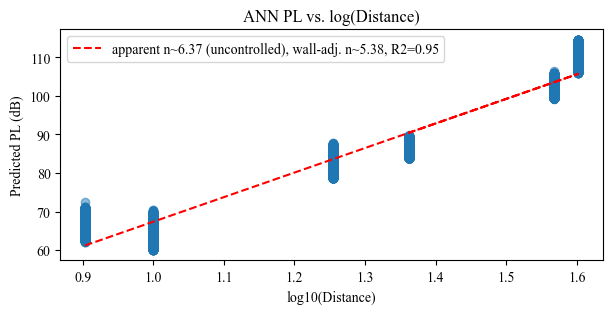

In [9]:
# Physics consistency: predicted PL vs. log10(distance), wall-adjusted exponent check
# PL(d) = PL(d0) + 10*n*log10(d/d0), so the log10(distance) OLS slope is 10*n, not n itself;
# wall count also correlates with distance in this dataset (r~0.79 for wood walls), so the
# uncontrolled slope partly reflects wall attenuation. Report both exponents.
dist = df_test["distance"].to_numpy()
log_dist = np.log10(dist + 1e-6)
slope, intercept, r_value, _, _ = linregress(log_dist, PL_pred_test)
n_apparent = slope / 10.0

wall_design = np.column_stack([
    np.ones_like(log_dist),
    log_dist,
    df_test["c_walls"].to_numpy(),
    df_test["w_walls"].to_numpy(),
])
wall_coefs, _, _, _ = np.linalg.lstsq(wall_design, PL_pred_test, rcond=None)
n_wall_adjusted = wall_coefs[1] / 10.0

plt.figure(figsize=(7, 3))
plt.scatter(log_dist, PL_pred_test, alpha=0.5)
plt.plot(
    log_dist, intercept + slope * log_dist, "r--",
    label=f"apparent n~{n_apparent:.2f} (uncontrolled), wall-adj. n~{n_wall_adjusted:.2f}, R2={r_value**2:.2f}",
)
plt.xlabel("log10(Distance)")
plt.ylabel("Predicted PL (dB)")
plt.title("ANN PL vs. log(Distance)")
plt.legend()
plt.show()

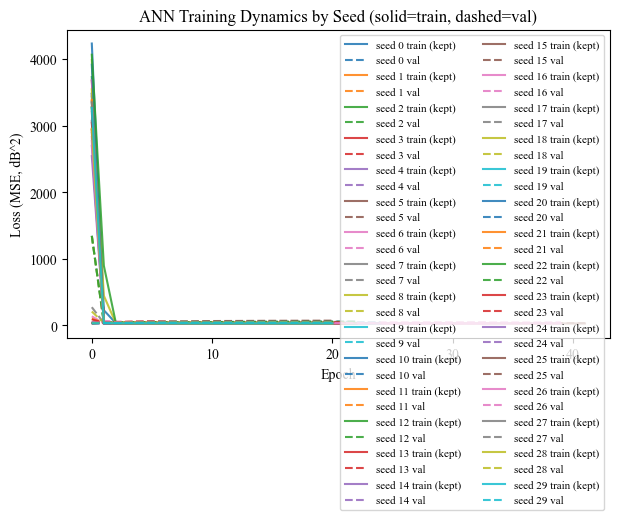

In [10]:
# Per-seed training dynamics: train/val loss by epoch for the final multi-seed ensemble.
# The collapse guard above only reports a pass/fail R2 per seed -- this shows *how* a
# seed converged (or didn't), and whether EarlyStopping/ReduceLROnPlateau triggered
# sensibly relative to their patience settings.
plt.figure(figsize=(7, 4))
for seed_idx, history in enumerate(final_seed_histories):
    status = "collapsed" if final_seed_collapsed[seed_idx] else "kept"
    color = f"C{seed_idx}"
    plt.plot(history["loss"], color=color, linestyle="-", alpha=0.85, label=f"seed {seed_idx} train ({status})")
    plt.plot(history["val_loss"], color=color, linestyle="--", alpha=0.85, label=f"seed {seed_idx} val")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE, dB^2)")
plt.title("ANN Training Dynamics by Seed (solid=train, dashed=val)")
plt.legend(fontsize=8, ncol=2)
plt.show()

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
ANN Architecture Performance Analysis
</p>

In [11]:
# Load ANN CV-summary results for plotting.
# Prefer the best-profile-per-architecture table so plots stay architecture-focused.
legacy_cv_result_paths = [
    os.path.join("ANN", "Results", "kfold_results_summary.csv"),
    os.path.join("Results", "kfold_results_summary.csv"),
]

if os.path.exists(BEST_PROFILE_PER_ARCH_PATH):
    model_results_df = pd.read_csv(BEST_PROFILE_PER_ARCH_PATH)
    mtime = pd.Timestamp.fromtimestamp(os.path.getmtime(BEST_PROFILE_PER_ARCH_PATH))
    print(f"Loaded {BEST_PROFILE_PER_ARCH_PATH} (last modified {mtime}).")
    print("If this is older than your most recent CV run, re-run the CV cell before trusting this plot.")
elif os.path.exists(CV_RESULTS_PATH):
    model_results_df = pd.read_csv(CV_RESULTS_PATH)
    if "Regularization Profile" in model_results_df.columns:
        rank_col = "Mean Val RMSE"  # selection criterion is the mean, so plot the mean
        model_results_df = (
            model_results_df
            .sort_values(by=rank_col, ascending=True)
            .groupby("Architecture", as_index=False)
            .head(1)
            .sort_values(by=rank_col, ascending=True)
        )
        model_results_df.to_csv(BEST_PROFILE_PER_ARCH_PATH, index=False)
else:
    model_results_df = None
    for legacy_path in legacy_cv_result_paths:
        if os.path.exists(legacy_path):
            model_results_df = pd.read_csv(legacy_path)
            model_results_df.to_csv(CV_RESULTS_PATH, index=False)
            print(f"Migrated legacy ANN CV results to: {CV_RESULTS_PATH}")
            break

    if model_results_df is None:
        raise FileNotFoundError(
            f"No ANN CV results found. Run the CV cell or provide {CV_RESULTS_PATH}."
        )

model_results_df


Loaded CV_Results/ann_compact_best_profile_per_architecture.csv (last modified 2026-10-05 02:23:27).
If this is older than your most recent CV run, re-run the CV cell before trusting this plot.


,Run Name,Architecture,Hidden Layers,Regularization Profile,L2 Reg,Dropout Rate,Learning Rate,Mean Val MSE,Std Val MSE,Mean Val MAE,...,Median Val RMSE,Std Val RMSE,Mean R2,Std R2,Mean Val MAPE (%),Std Val MAPE (%),Mean Val MedAE,Std Val MedAE,Failed Folds,Retried Folds
0,L2_16_8__mild_both,L2_16_8,"[16, 8]",mild_both,0.0001,0.1,0.001,43.439832,6.343066,5.000391,...,6.509802,0.488029,0.852712,0.032560,5.890448,0.555500,4.019011,0.362555,0,0
1,L2_40_20__dropout_only,L2_40_20,"[40, 20]",dropout_only,0.0000,0.1,0.001,44.436369,10.150498,5.043239,...,6.527319,0.764121,0.848768,0.047155,5.938267,0.818053,4.061693,0.539670,0,0
2,L2_50_25__l2_only,L2_50_25,"[50, 25]",l2_only,0.0001,0.0,0.001,49.322083,7.518671,5.347715,...,6.639996,0.529299,0.832594,0.040413,6.263096,0.614913,4.296788,0.419713,0,0
3,L2_24_12__dropout_only,L2_24_12,"[24, 12]",dropout_only,0.0000,0.1,0.001,44.829063,5.700796,5.050360,...,6.659283,0.425830,0.848194,0.031512,5.875876,0.408591,4.023563,0.198221,0,0
4,L2_20_10__l2_only,L2_20_10,"[20, 10]",l2_only,0.0001,0.0,0.001,45.084617,9.450674,5.150197,...,6.715892,0.722837,0.846768,0.041376,6.113557,0.787843,4.200030,0.531642,0,0
5,L2_28_14__none,L2_28_14,"[28, 14]",none,0.0000,0.0,0.001,47.504171,6.803476,5.270406,...,6.726519,0.491598,0.838826,0.037003,6.224260,0.634464,4.251625,0.394575,0,0
6,L3_16_8_4__l2_only,L3_16_8_4,"[16, 8, 4]",l2_only,0.0001,0.0,0.001,55.430361,23.583440,5.552387,...,6.945863,1.489533,0.811663,0.085463,6.587288,1.097518,4.413942,0.635410,0,0
7,L2_32_16__l2_only,L2_32_16,"[32, 16]",l2_only,0.0001,0.0,0.001,48.190741,7.922066,5.269186,...,6.973307,0.596400,0.836079,0.040853,6.218702,0.697359,4.198838,0.475710,0,0
8,L2_12_6__l2_only,L2_12_6,"[12, 6]",l2_only,0.0001,0.0,0.001,46.677437,11.529151,5.224599,...,7.109361,0.885728,0.840911,0.048510,6.196830,0.889356,4.244036,0.552156,0,0
9,L3_40_20_10__l2_only,L3_40_20_10,"[40, 20, 10]",l2_only,0.0001,0.0,0.001,51.320478,9.975157,5.515580,...,7.128802,0.698791,0.825486,0.048468,6.516066,0.803726,4.545295,0.527616,0,0


In [12]:

# Define the function to sum hidden layers
def sum_hidden_layers(hidden_layers_str):
    # Convert string representation of list to an actual list
    hidden_layers = ast.literal_eval(hidden_layers_str)
    # Calculate and return the sum
    return sum(hidden_layers)

# Define a function to count the number of hidden layers
def count_hidden_layers(hidden_layers_str):
    # Convert string representation of list to an actual list
    hidden_layers = ast.literal_eval(hidden_layers_str)
    # Return the number of layers
    return len(hidden_layers)

# Apply the function to create 'Total Nodes' column
model_results_df['Total Nodes'] = model_results_df['Hidden Layers'].apply(sum_hidden_layers)

# Apply the function to create 'Number of Layers' column
model_results_df['Number of Layers'] = model_results_df['Hidden Layers'].apply(count_hidden_layers)

# Rename columns (your requested names). Prefer the median-based RMSE column
# (robust to a single collapsed-then-retried fold) if present, so the plotted
# metric matches the one actually used to select the "best" architecture.
_rmse_source_col = "Mean Val RMSE"  # selection criterion is the mean, so plot the mean
model_results_df.rename(
    columns={
        _rmse_source_col: "Test RMSE",
        "Mean R2": "R2 Score",
        "Std Val RMSE": "Std RMSE"
    },
    inplace=True
)

model_results_df


,Run Name,Architecture,Hidden Layers,Regularization Profile,L2 Reg,Dropout Rate,Learning Rate,Mean Val MSE,Std Val MSE,Mean Val MAE,...,R2 Score,Std R2,Mean Val MAPE (%),Std Val MAPE (%),Mean Val MedAE,Std Val MedAE,Failed Folds,Retried Folds,Total Nodes,Number of Layers
0,L2_16_8__mild_both,L2_16_8,"[16, 8]",mild_both,0.0001,0.1,0.001,43.439832,6.343066,5.000391,...,0.852712,0.032560,5.890448,0.555500,4.019011,0.362555,0,0,24,2
1,L2_40_20__dropout_only,L2_40_20,"[40, 20]",dropout_only,0.0000,0.1,0.001,44.436369,10.150498,5.043239,...,0.848768,0.047155,5.938267,0.818053,4.061693,0.539670,0,0,60,2
2,L2_50_25__l2_only,L2_50_25,"[50, 25]",l2_only,0.0001,0.0,0.001,49.322083,7.518671,5.347715,...,0.832594,0.040413,6.263096,0.614913,4.296788,0.419713,0,0,75,2
3,L2_24_12__dropout_only,L2_24_12,"[24, 12]",dropout_only,0.0000,0.1,0.001,44.829063,5.700796,5.050360,...,0.848194,0.031512,5.875876,0.408591,4.023563,0.198221,0,0,36,2
4,L2_20_10__l2_only,L2_20_10,"[20, 10]",l2_only,0.0001,0.0,0.001,45.084617,9.450674,5.150197,...,0.846768,0.041376,6.113557,0.787843,4.200030,0.531642,0,0,30,2
5,L2_28_14__none,L2_28_14,"[28, 14]",none,0.0000,0.0,0.001,47.504171,6.803476,5.270406,...,0.838826,0.037003,6.224260,0.634464,4.251625,0.394575,0,0,42,2
6,L3_16_8_4__l2_only,L3_16_8_4,"[16, 8, 4]",l2_only,0.0001,0.0,0.001,55.430361,23.583440,5.552387,...,0.811663,0.085463,6.587288,1.097518,4.413942,0.635410,0,0,28,3
7,L2_32_16__l2_only,L2_32_16,"[32, 16]",l2_only,0.0001,0.0,0.001,48.190741,7.922066,5.269186,...,0.836079,0.040853,6.218702,0.697359,4.198838,0.475710,0,0,48,2
8,L2_12_6__l2_only,L2_12_6,"[12, 6]",l2_only,0.0001,0.0,0.001,46.677437,11.529151,5.224599,...,0.840911,0.048510,6.196830,0.889356,4.244036,0.552156,0,0,18,2
9,L3_40_20_10__l2_only,L3_40_20_10,"[40, 20, 10]",l2_only,0.0001,0.0,0.001,51.320478,9.975157,5.515580,...,0.825486,0.048468,6.516066,0.803726,4.545295,0.527616,0,0,70,3


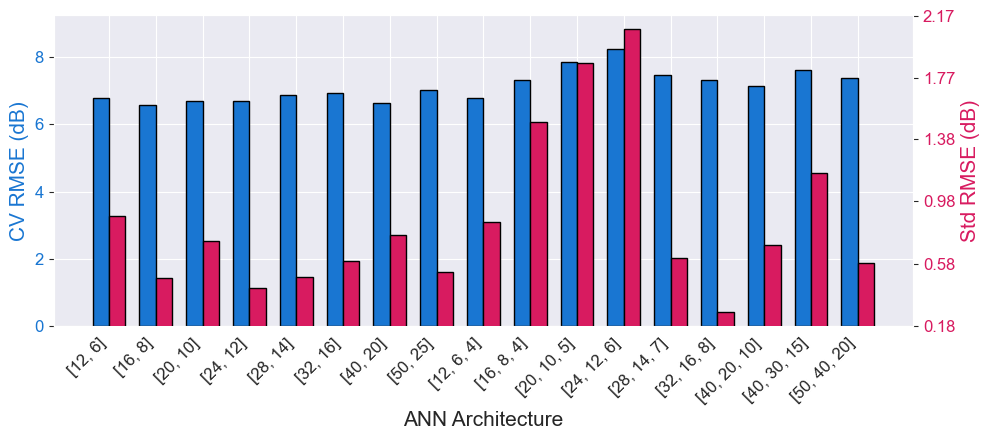

In [13]:
# Sort by Test RMSE
model_results_df_sorted = model_results_df.sort_values(by='Test RMSE', ascending=True)

# FONT SIZES 
tick_fontsize = 12
axis_labelsize = 15

sns.set_style("darkgrid")

model_results_df_filtered_sorted = model_results_df_sorted.copy()
model_results_df_filtered_sorted["Total Nodes"] = pd.to_numeric(model_results_df_filtered_sorted["Total Nodes"], errors="coerce")
model_results_df_filtered_sorted["Number of Hidden Layers"] = model_results_df_filtered_sorted["Hidden Layers"].apply(lambda v: len(v) if isinstance(v, (list, tuple)) else len([x for x in str(v).replace("[", "").replace("]", "").replace("(", "").replace(")", "").split(",") if x.strip()]))

model_results_df_filtered_sorted = model_results_df_filtered_sorted.sort_values(by=["Number of Hidden Layers", "Total Nodes"], ascending=[True, True]).reset_index(drop=True)

x = np.arange(len(model_results_df_filtered_sorted))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 4.5))

rmse_color = "#1976d2"
std_color  = "#d81b60"

ax1.bar(x - bar_width/2, model_results_df_filtered_sorted["Test RMSE"], bar_width, color=rmse_color, edgecolor="black", linewidth=1, zorder=3)

ax1.set_xlabel("ANN Architecture", fontsize=axis_labelsize)
ax1.set_xticks(x)
ax1.set_xticklabels(model_results_df_filtered_sorted["Hidden Layers"], rotation=45, ha="right", fontsize=tick_fontsize)

ax1.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize, color=rmse_color)
ax1.tick_params(axis="y", labelcolor=rmse_color, labelsize=tick_fontsize)
ax1.grid(True, axis="y")
ax1.set_ylim(0, model_results_df_filtered_sorted["Test RMSE"].max() * 1.12)

ax2 = ax1.twinx()
ax2.bar(x + bar_width/2, model_results_df_filtered_sorted["Std RMSE"], bar_width, color=std_color, edgecolor="black", linewidth=1, zorder=3)

ax2.set_ylabel("Std RMSE (dB)", fontsize=axis_labelsize, color=std_color)
ax2.tick_params(axis="y", labelcolor=std_color, labelsize=tick_fontsize)
ax2.grid(False)

std = model_results_df_filtered_sorted["Std RMSE"].astype(float).to_numpy()
std_min, std_max = float(std.min()), float(std.max())
pad = 0.05 * (std_max - std_min) if std_max > std_min else 0.05
std_low, std_high = max(0.0, std_min - pad), std_max + pad

ax2.set_ylim(std_low, std_high)
ax2.set_yticks(np.round(np.linspace(std_low, std_high, 6), 2))

fig.tight_layout()
plt.show()

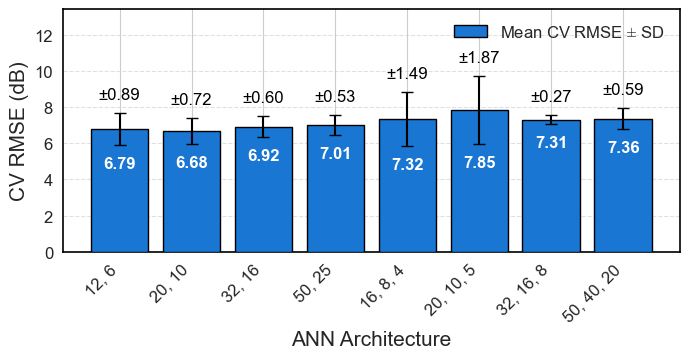

In [14]:
# Plot and save the focused ANN CV RMSE figure based on selected architectures

tick_fontsize   = 12
axis_labelsize  = 15
legend_fontsize = 12

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
sns.set_style("whitegrid")

TARGET_ARCHS = [
    (12, 6),
    (20, 10),
    (32, 16),
    (50, 25),
    (16, 8, 4),
    (20, 10, 5),
    (32, 16, 8),
    (50, 40, 20),
]

def arch_to_tuple(v):
    if isinstance(v, (list, tuple, np.ndarray)):
        return tuple(int(x) for x in v)
    nums = re.findall(r"\d+", str(v))
    return tuple(int(n) for n in nums)

def tuple_to_label(t):
    return ", ".join(map(str, t))

df_plot = model_results_df_sorted.copy()

rmse_col = "Test RMSE" if "Test RMSE" in df_plot.columns else "Mean Val RMSE"
std_col = "Std RMSE" if "Std RMSE" in df_plot.columns else "Std Val RMSE"

df_plot["arch_tuple"] = df_plot["Hidden Layers"].apply(arch_to_tuple)
df_plot = df_plot[df_plot["arch_tuple"].isin(TARGET_ARCHS)].copy()

df_plot["CV_RMSE"] = pd.to_numeric(df_plot[rmse_col], errors="coerce")
df_plot["STD_RMSE"] = pd.to_numeric(df_plot[std_col], errors="coerce")
df_plot["Total Nodes"] = pd.to_numeric(df_plot["Total Nodes"], errors="coerce")
df_plot["Number of Hidden Layers"] = df_plot["arch_tuple"].apply(len)

df_plot = df_plot.sort_values(
    by=["Number of Hidden Layers", "Total Nodes"],
    ascending=[True, True]
).reset_index(drop=True)

df_plot["arch_label"] = df_plot["arch_tuple"].apply(tuple_to_label)

if df_plot.empty:
    raise ValueError("No selected ANN architectures found for plotting.")

x = np.arange(len(df_plot))
bar_width = 0.8

fig, ax = plt.subplots(figsize=(7, 3.7))

bars = ax.bar(
    x,
    df_plot["CV_RMSE"],
    width=bar_width,
    yerr=df_plot["STD_RMSE"],
    capsize=4,
    color="#1976d2",
    edgecolor="black",
    linewidth=1,
    zorder=3,
    label=r"Mean CV RMSE $\pm$ SD"
)

ax.set_xlabel("ANN Architecture", fontsize=axis_labelsize)
ax.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize)

ax.set_xticks(x)
ax.set_xticklabels(
    df_plot["arch_label"],
    rotation=45,
    ha="right",
    fontsize=tick_fontsize
)

ax.tick_params(axis="y", labelsize=tick_fontsize)
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

for i, row in df_plot.iterrows():
    ax.annotate(
        f'{row["CV_RMSE"]:.2f}',
        (x[i], row["CV_RMSE"] - row["STD_RMSE"]),
        textcoords="offset points",
        xytext=(0, -8),
        ha="center",
        va="top",
        fontsize=tick_fontsize,
        color="white",
        fontweight="bold"
    )

for i, row in df_plot.iterrows():
    ax.annotate(
        f'±{row["STD_RMSE"]:.2f}',
        (x[i], row["CV_RMSE"] + row["STD_RMSE"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        va="bottom",
        fontsize=12,
        color="#000000"
    )

ymax = float((df_plot["CV_RMSE"] + df_plot["STD_RMSE"]).max())
ax.set_ylim(0, ymax * 1.38)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("black")
    spine.set_linewidth(1.2)

ax.legend(
    loc="upper right",
    fontsize=legend_fontsize,
    frameon=False
)

fig.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "ANN_RMSE_STD_selected_archs.png")
#fig.savefig(fig_path, dpi=600, bbox_inches="tight", pad_inches=0.03)

plt.show()